# MHCII-NA neuts using H5 HA

## Set up analysis
Import packages

In [18]:
import os
import re
import warnings

from IPython.display import display, HTML

import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib as mpl
import matplotlib.pyplot as plt
import natsort

import numpy as np
import pandas as pd
from plotnine import *

import neutcurve
from neutcurve.colorschemes import CBMARKERS, CBPALETTE

# import lifelines
# import sklearn
import scipy.stats
import altair as alt

import yaml

print(f"Using `neutcurve` version {neutcurve.__version__}")

Using `neutcurve` version 2.3.0


Use seaborn theme and change font:

In [19]:
theme_set(theme_seaborn(style='white', context='talk', font='FreeSans', font_scale=1))


Read in config file

In [20]:
with open('config.yaml') as f:
    config = yaml.safe_load(f)

Define results directory

In [21]:
resultsdir = 'results/neuts'
os.makedirs(resultsdir, exist_ok=True)

## Read in fracinfect file and plot curves

In [22]:
frac_infect = (pd.read_csv(config['fract_infect'])
              )

fits = neutcurve.CurveFits(frac_infect)

fitparams = (
    fits.fitParams(ics=[50])
    .assign(NT50=lambda x: 1/x['ic50'])
    )

# couldn't get lambda / conditional statement to work with assign, so try it here:
fitparams['ic50_is_bound'] = fitparams['ic50_bound'].apply(lambda x: True if x!='interpolated' else False)

In [23]:
fitparams.to_csv('ICXX.csv', index=False) # index=False prevents saving the index


Saving to results/neuts/frac_infectivity.png


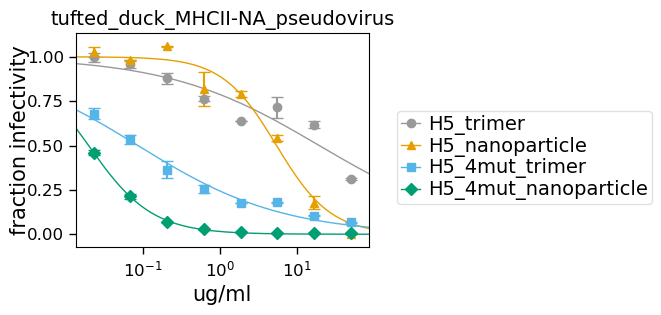

In [24]:
fig, axes = fits.plotSera(
    xlabel='ug/ml',
    legendfontsize=14,
    max_viruses_per_subplot=7
)

plotfile = f'{resultsdir}/frac_infectivity.png'
print(f"Saving to {plotfile}")
fig.savefig(plotfile, bbox_inches='tight')

## Interactive neutralization curves with `altair`

Re-plot the fitted neutralization curves with `altair` (smooth Hill-curve fits + mean
data points with error bars), in the same style as the
[Flu-H5N1-American-Wigeon DMS validations notebook](https://github.com/dms-vep/Flu-H5N1-American-Wigeon-2021-HA-MHCII-DMS/blob/main/analysis_notebooks/MHCII_VLP_neutralization_DMS_validations/neuts_altair_dms_validations.ipynb).

In [25]:

alt.data_transformers.disable_max_rows()

# ── Virus order and color mapping ─────────────────────────────────────────────
# build the order from the data, but keep a sensible manual order if it matches
virus_order = [
    'H5_trimer', 'H5_nanoparticle', 'H5_4mut_trimer', 'H5_4mut_nanoparticle',
]
# fall back to whatever is actually present (preserves manual order, appends extras)
present = list(frac_infect['virus'].unique())
virus_order = [v for v in virus_order if v in present] + [v for v in present if v not in virus_order]

tableau10 = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f',
    '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac', '#7EB77F',
]
color_map = {v: tableau10[i % len(tableau10)] for i, v in enumerate(virus_order)}
COLOR_SCALE = alt.Scale(domain=list(color_map.keys()), range=list(color_map.values()))

# ── Smooth fitted Hill curves (from the `fits` object, averaged over replicates) ──
smooth_df = pd.concat(
    [
        fits.getCurve(serum=serum, virus=virus, replicate='average')
        .dataframe()[['concentration', 'fit']]
        .assign(serum=serum, virus=virus)
        for serum in frac_infect['serum'].unique()
        for virus in virus_order
    ],
    ignore_index=True,
)

# clamp the smooth fit to the measured concentration range, since `neutcurve`
# extends its fit grid slightly beyond the data
conc_min = frac_infect['concentration'].min()
conc_max = frac_infect['concentration'].max()
smooth_df = smooth_df[
    smooth_df['concentration'].between(conc_min, conc_max)
]

# pad the x-axis a bit on each side (multiplicative, since the scale is log) so the
# lowest/highest concentration points don't sit right on the plot edges
x_pad = 2.0
x_scale = alt.Scale(type='log', domain=[conc_min / x_pad, conc_max * x_pad], nice=False)

# ── Aggregate data (mean ± std across replicates) ─────────────────────────────
frac_infect_agg = (
    frac_infect
    .groupby(['serum', 'virus', 'concentration'])
    .agg({'fraction infectivity': ['mean', 'std', 'count']})
    .reset_index()
)
frac_infect_agg.columns = ['serum', 'virus', 'concentration', 'mean_frac_infectivity', 'std_frac_infectivity', 'n_replicates']
frac_infect_agg['std_frac_infectivity'] = frac_infect_agg['std_frac_infectivity'].fillna(0)
frac_infect_agg['upper_bound'] = np.clip(frac_infect_agg['mean_frac_infectivity'] + frac_infect_agg['std_frac_infectivity'], 0, 1.1)
frac_infect_agg['lower_bound'] = np.clip(frac_infect_agg['mean_frac_infectivity'] - frac_infect_agg['std_frac_infectivity'], 0, 1.1)

# ── Shared encoding helpers ───────────────────────────────────────────────────
x_enc = alt.X(
    'concentration:Q',
    scale=x_scale,
    title='concentration (µg/ml)',
    axis=alt.Axis(format='.0e', labelAngle=-45, grid=False),
)
y_enc = alt.Y(
    'fit:Q',
    title='fraction infectivity',
    scale=alt.Scale(domain=[0, 1.1]),
    axis=alt.Axis(grid=False),
)
color_enc = alt.Color(
    'virus:N',
    scale=COLOR_SCALE,
    title='Virus',
    sort=virus_order,
)

# ── Layer 1: smooth fitted lines ──────────────────────────────────────────────
line_layer = (
    alt.Chart(smooth_df)
    .mark_line(strokeWidth=3)
    .encode(
        x=x_enc,
        y=y_enc,
        color=color_enc,
        tooltip=[
            alt.Tooltip('virus:N', title='Virus'),
            alt.Tooltip('concentration:Q', title='Concentration', format='.4e'),
            alt.Tooltip('fit:Q', title='Fitted frac. infect.', format='.3f'),
        ],
    )
)

# ── Layer 2: error bars ───────────────────────────────────────────────────────
error_layer = (
    alt.Chart(frac_infect_agg)
    .mark_errorbar(opacity=0.6, thickness=2, size=8)
    .encode(
        x=alt.X('concentration:Q', scale=x_scale),
        y=alt.Y('lower_bound:Q', title='fraction infectivity'),
        y2='upper_bound:Q',
        color=color_enc,
    )
)

# ── Layer 3: mean data points ─────────────────────────────────────────────────
scatter_layer = (
    alt.Chart(frac_infect_agg)
    .mark_point(size=130, filled=True, opacity=0.85, stroke='white', strokeWidth=1.5)
    .encode(
        x=alt.X('concentration:Q', scale=x_scale),
        y=alt.Y('mean_frac_infectivity:Q', title='fraction infectivity'),
        color=color_enc,
        tooltip=[
            alt.Tooltip('virus:N', title='Virus'),
            alt.Tooltip('serum:N', title='Serum'),
            alt.Tooltip('concentration:Q', title='Concentration', format='.4e'),
            alt.Tooltip('mean_frac_infectivity:Q', title='Mean frac. infectivity', format='.3f'),
            alt.Tooltip('std_frac_infectivity:Q', title='Std dev', format='.3f'),
            alt.Tooltip('n_replicates:Q', title='N replicates'),
        ],
    )
)

# ── Combine layers ────────────────────────────────────────────────────────────
chart = (
    (line_layer + error_layer + scatter_layer)
    .properties(
        width=320,
        height=320,
        title=alt.TitleParams(
            'tufted-duck-MHCII H5 HA neutralization',
            fontSize=17,
            anchor='start',
        ),
    )
    .resolve_scale(color='shared', shape='shared')
    .configure_axis(labelFontSize=12, titleFontSize=13)
    .configure_legend(labelFontSize=11, titleFontSize=12)
)

chartfile = f'{resultsdir}/neuts_altair.html'
print(f"Saving to {chartfile}")
chart.save(chartfile)

chart

Saving to results/neuts/neuts_altair.html


alt.LayerChart(...)